# Customer Segmentation

## Supervised and Unsupervised Learning

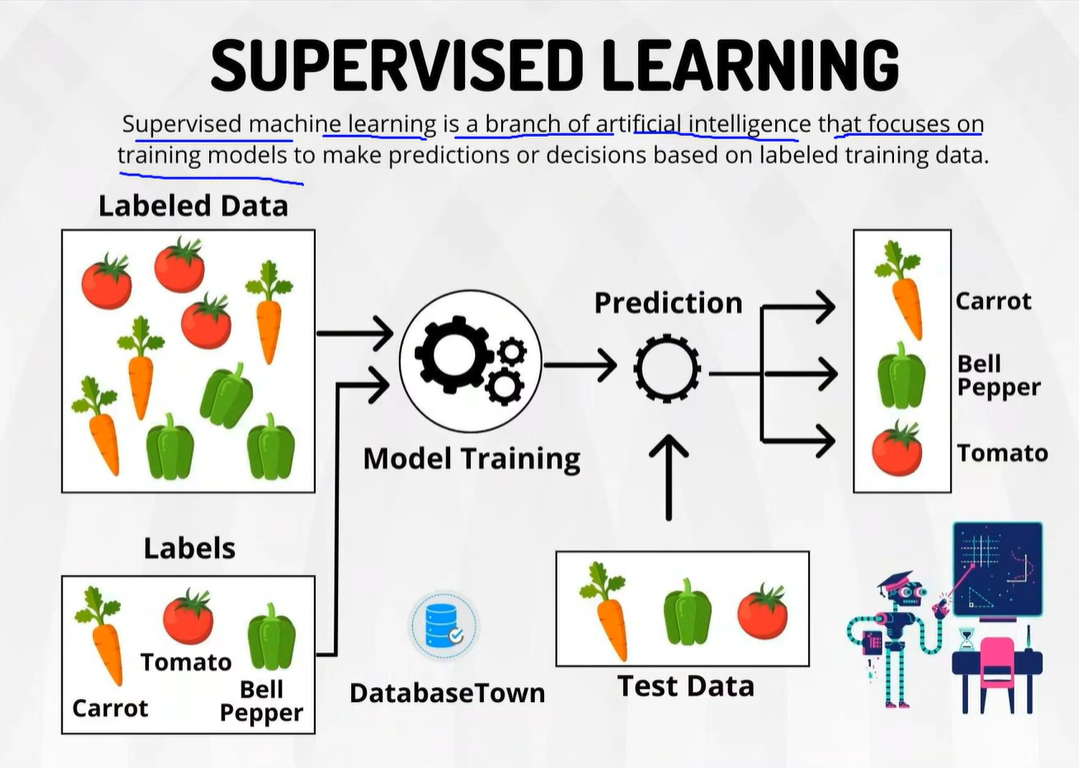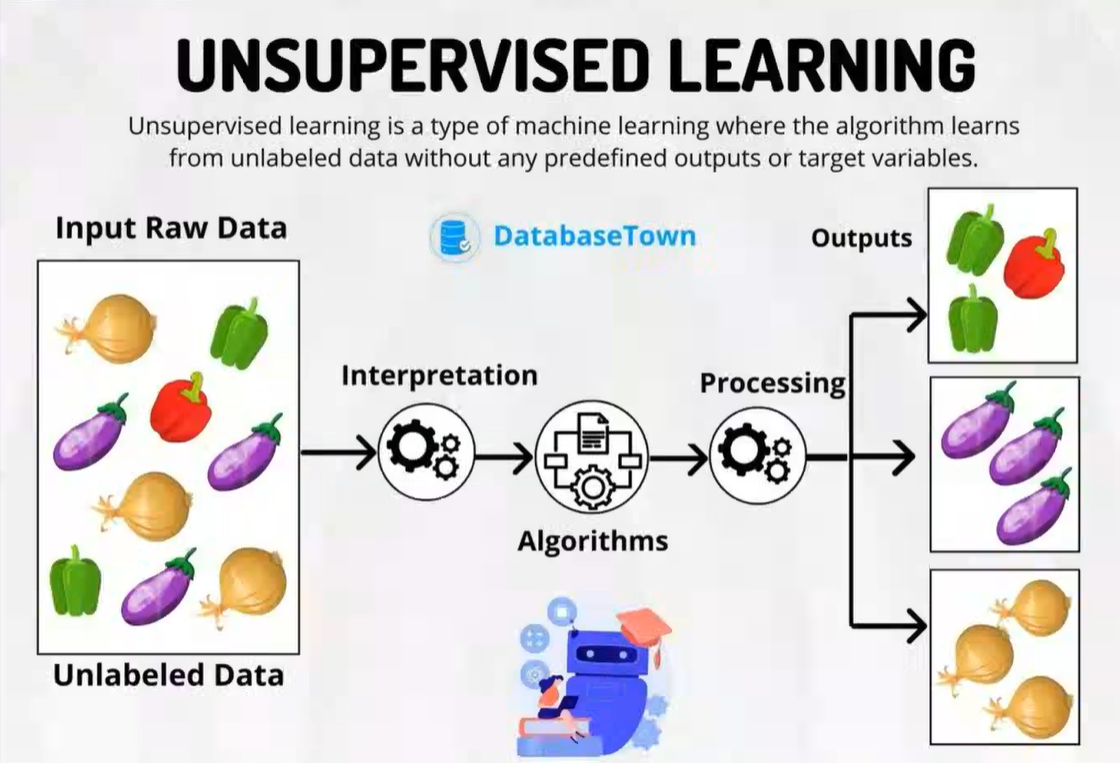

## Importing the dataset

In [1]:
import pandas as pd

In [3]:
dataset = pd.read_csv("Wholesale customers data.csv")

In [5]:
dataset.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## A quick exploration of the data

In [9]:
dataset.shape

(440, 8)

In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [11]:
dataset.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


## Checking histograms

In [12]:
import matplotlib.pyplot as plt

In [25]:
spend_cols = ["Fresh","Milk","Grocery","Frozen","Detergents_Paper","Delicassen"]

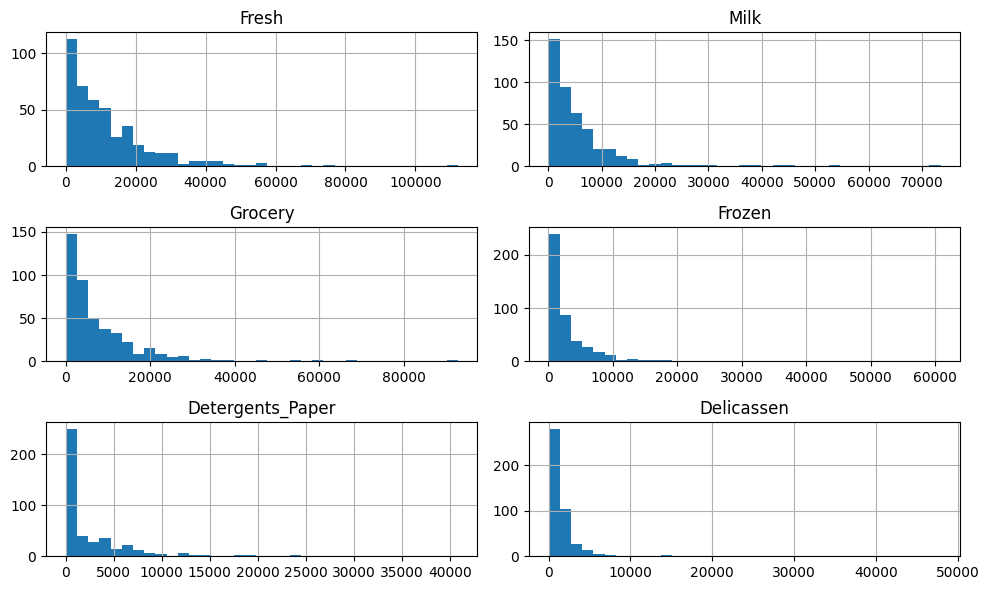

In [27]:
dataset[spend_cols].hist(bins=35, figsize=(10,6))
plt.tight_layout()

What is scewed data.. what is normal distridution and what is positive distribution.

## Data Preprocessing

In [30]:
X = dataset[spend_cols]

In [35]:
X

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...
435,29703,12051,16027,13135,182,2204
436,39228,1431,764,4510,93,2346
437,14531,15488,30243,437,14841,1867
438,10290,1981,2232,1038,168,2125


In [32]:
import numpy as np

In [33]:
X_log = np.log1p(X)

In [36]:
X_log

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718
...,...,...,...,...,...,...
435,10.299037,9.396986,9.682092,9.483112,5.209486,7.698483
436,10.577172,7.266827,6.639876,8.414274,4.543295,7.760893
437,9.584108,9.647885,10.317053,6.082219,9.605216,7.532624
438,9.239025,7.591862,7.711101,6.946014,5.129899,7.661998


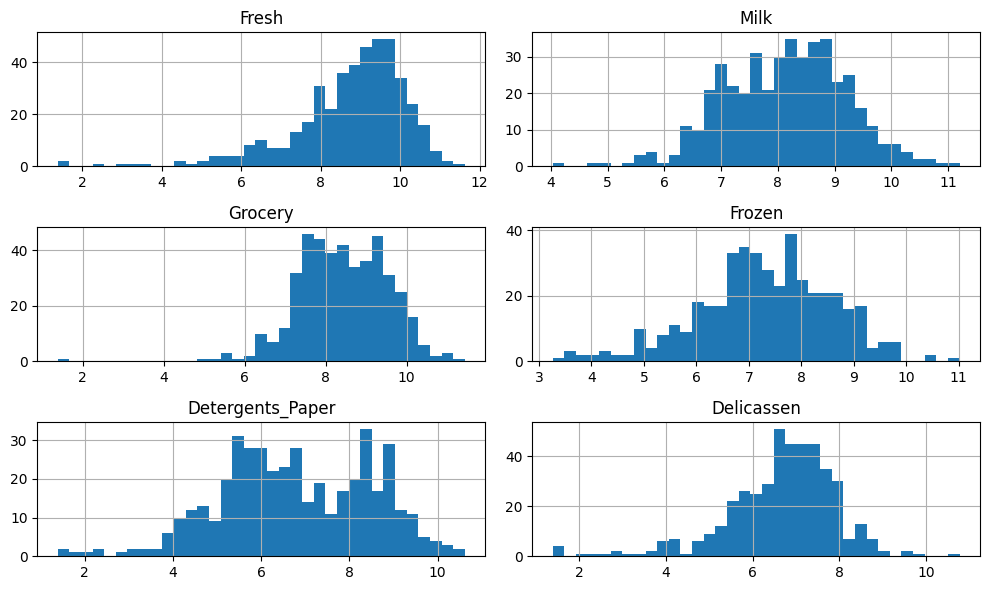

In [38]:
X_log.hist(bins=35, figsize=(10,6))
plt.tight_layout()

## Feature Scaling

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

In [42]:
print(X_scaled)

[[ 0.4861845   0.97629884  0.44015468 -1.50924981  0.64414327  0.40896595]
 [ 0.08788863  0.99095612  0.65217085  0.13405226  0.76604314  0.62792606]
 [ 0.01635628  0.89115098  0.45468702  0.37689926  0.80440496  1.77683339]
 ...
 [ 0.57952767  1.41399051  1.68865731 -0.95351417  1.64761948  0.66656608]
 [ 0.34460869 -0.49078257 -0.65849797 -0.27890118 -0.97324089  0.76666284]
 [-0.54442663 -0.63351532 -0.55281539 -2.43158276 -0.36435895 -2.0896139 ]]
